# CHƯƠNG 5: PHÂN TÍCH PHÂN LOẠI VỚI HỒI QUY LOGISTIC

Trong các chương trước, chúng ta đã sử dụng Hồi quy tuyến tính đa biến (OLS) để dự báo một biến phụ thuộc $Y$ liên tục (như Giá nhà, Doanh thu). Tuy nhiên, trong Tài chính và Kinh doanh, những câu hỏi mang tính sống còn thường tồn tại dưới dạng Nhị phân (Binary): Khách hàng có vỡ nợ hay không (1/0)? Giao dịch này có phải là gian lận hay không (1/0)? Khách hàng có click vào quảng cáo hay không (1/0)? 

Khi đối mặt với không gian trạng thái rời rạc này, mô hình OLS bộc lộ những lỗ hổng toán học nghiêm trọng, đòi hỏi sự ra đời của Hồi quy Logistic và Hàm liên kết (Link Function).

---

## 5.1. Tại sao không dùng OLS cho biến phụ thuộc nhị phân (Binary Y)?

Nếu chúng ta cố chấp áp dụng Hồi quy tuyến tính (OLS) để dự báo một biến $Y \in \{0, 1\}$, mô hình này được gọi là **Mô hình Xác suất Tuyến tính (Linear Probability Model - LPM)**. Phương trình có dạng:

$$E[Y_i | \mathbf{X}_i] = P(Y_i = 1 | \mathbf{X}_i) = p_i = \mathbf{X}_i \boldsymbol{\beta}$$

Về mặt lý thuyết, LPM dự báo xác suất $p_i$ xảy ra sự kiện (VD: Vỡ nợ). Tuy nhiên, cách tiếp cận này phá vỡ 2 nền tảng cốt lõi của toán học và thống kê.

### 5.1.1. Lỗ hổng thứ nhất: Dự báo nằm ngoài không gian xác suất $[0, 1]$
Theo tiên đề xác suất của Kolmogorov, mọi xác suất $P(A)$ đều phải bị chặn trong khoảng $[0, 1]$. 
Tuy nhiên, hàm tuyến tính $f(\mathbf{X}) = \beta_0 + \beta_1 X_1 + \dots + \beta_k X_k$ là một hàm không bị chặn. Nó có tập giá trị trải dài từ $-\infty$ đến $+\infty$.

**Hệ quả thực tiễn:** Giả sử bạn xây dựng mô hình dự báo xác suất vỡ nợ dựa trên Dư nợ thẻ tín dụng. Nếu dư nợ của khách hàng quá thấp, OLS có thể trả về dự báo xác suất vỡ nợ là **$-0.15$ (Âm 15%)**. Ngược lại, nếu dư nợ quá cao, mô hình có thể dự báo xác suất vỡ nợ là **$1.25$ (125%)**. Những con số này hoàn toàn vô nghĩa về mặt logic toán học và không thể sử dụng để ra quyết định quản trị rủi ro.

### 5.1.2. Lỗ hổng thứ hai: Vi phạm giả định Phương sai sai số không đổi (Heteroskedasticity)
Hãy nhớ lại định lý Gauss-Markov: OLS chỉ là ước lượng tốt nhất (BLUE) nếu phương sai của sai số $\epsilon_i$ là một hằng số.

Với biến $Y_i$ nhị phân, nó tuân theo **Phân phối Bernoulli (Bernoulli Distribution)**. 
Theo lý thuyết xác suất, phương sai của một biến ngẫu nhiên Bernoulli phụ thuộc trực tiếp vào kỳ vọng (xác suất) của nó:
$$Var(Y_i | \mathbf{X}_i) = p_i (1 - p_i)$$

Vì mô hình LPM định nghĩa $p_i = \mathbf{X}_i \boldsymbol{\beta}$, ta có phương sai của phần dư là:
$$Var(\epsilon_i | \mathbf{X}_i) = (\mathbf{X}_i \boldsymbol{\beta}) (1 - \mathbf{X}_i \boldsymbol{\beta})$$

**Kết luận chấn động:** Phương sai của sai số thay đổi liên tục và phụ thuộc trực tiếp vào biến độc lập $\mathbf{X}_i$. Ở những khách hàng có xác suất vỡ nợ rất thấp (như 0.01) hoặc rất cao (như 0.99), phương sai xấp xỉ 0. Nhưng ở những khách hàng mấp mé biên giới (xác suất 0.5), phương sai đạt cực đại là 0.25. 
Sự hiện diện của **Heteroskedasticity** mang tính hệ thống này phá hủy hoàn toàn độ tin cậy của các Sai số chuẩn (Standard Errors), khiến mọi phép kiểm định t-test và p-value của OLS trở nên vô giá trị.

---

## 5.2. Hàm Logistic và Kỷ nguyên của Tỷ lệ chênh (Odds Ratio)

Để sửa chữa các lỗ hổng của OLS, chúng ta cần một phép biến đổi toán học (Link Function) có khả năng "bóp méo" một trục số thực kéo dài từ $(-\infty, +\infty)$ ép gọn vào trong khoảng $(0, 1)$. Phép biến đổi đó chính là **Hàm Logit (Logit Transformation)**.

### 5.2.1. Định lý về Tỷ lệ chênh (Odds)
Thay vì mô hình hóa trực tiếp xác suất $p$, thống kê suy diễn định nghĩa khái niệm **Odds (Tỷ lệ chênh)**. 
Odds là tỷ lệ giữa xác suất sự kiện xảy ra chia cho xác suất sự kiện không xảy ra:

$$\text{Odds} = \frac{p}{1 - p}$$

**Diễn giải:** Nếu xác suất ngựa đua số 1 chiến thắng là $p = 0.8$ (80%), thì xác suất thua là $1 - p = 0.2$ (20%). 
Tỷ lệ chênh $\text{Odds} = 0.8 / 0.2 = 4$. Trong ngôn ngữ cá cược, tỷ lệ này được gọi là "4 ăn 1" (4 to 1 odds). Mặc dù xác suất $p$ bị giới hạn trong $[0, 1]$, nhưng $\text{Odds}$ có miền giá trị mở rộng từ $[0, +\infty)$.

### 5.2.2. Biến đổi Logit (Logit Link Function)
Mặc dù Odds đã mở rộng được chặn trên lên vô cực, chặn dưới của nó vẫn là 0. Để không gian này thực sự đối xứng và trải dài ra toàn bộ trục số thực $(-\infty, +\infty)$, chúng ta lấy Logarit tự nhiên (Natural Logarithm) của Odds. Đây được gọi là hàm Logit:

$$\text{Logit}(p) = \ln(\text{Odds}) = \ln\left(\frac{p}{1 - p}\right) = Z$$

Bây giờ, đại lượng $Z$ (Log-odds) đã là một biến số liên tục không bị giới hạn. Chúng ta có thể mạnh dạn áp dụng Hồi quy tuyến tính lên đại lượng $Z$ này:

$$\ln\left(\frac{p}{1 - p}\right) = \beta_0 + \beta_1 X_1 + \dots + \beta_k X_k = \mathbf{X}\boldsymbol{\beta}$$

### 5.2.3. Hàm Sigmoid (Inverse Logit)
Mô hình tuyến tính giải thích Log-odds, nhưng mục tiêu cuối cùng của ngân hàng là tính ra con số xác suất $p$ để duyệt vay. Chúng ta cần giải phương trình trên để cô lập $p$ (Inverse Transformation).

Lấy e mũ hai vế (Exponentiating):
$$\frac{p}{1 - p} = e^{\mathbf{X}\boldsymbol{\beta}}$$
$$p = e^{\mathbf{X}\boldsymbol{\beta}} (1 - p)$$
$$p = e^{\mathbf{X}\boldsymbol{\beta}} - p \cdot e^{\mathbf{X}\boldsymbol{\beta}}$$
$$p(1 + e^{\mathbf{X}\boldsymbol{\beta}}) = e^{\mathbf{X}\boldsymbol{\beta}}$$
$$p = \frac{e^{\mathbf{X}\boldsymbol{\beta}}}{1 + e^{\mathbf{X}\boldsymbol{\beta}}}$$

Chia cả tử và mẫu cho $e^{\mathbf{X}\boldsymbol{\beta}}$, ta thu được **Hàm Sigmoid (Logistic Function)** trứ danh:

$$p = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \dots + \beta_k X_k)}} = \frac{1}{1 + e^{-Z}}$$

Đặc tính của Sigmoid là đường cong hình chữ S: Dù tổng tín hiệu đầu vào $Z$ có âm vô cực hay dương vô cực đi chăng nữa, giá trị trả về luôn tiệm cận về 0 hoặc 1 một cách mượt mà.

---

### 5.2.4. Diễn giải Hệ số $\beta$ trong Mô hình Logistic (Odds Ratio)

Trong OLS, $\beta_1$ có nghĩa là "khi X tăng 1 đơn vị, Y tăng $\beta_1$ đơn vị". Nhưng trong Hồi quy Logistic, $Y$ không quan sát được trực tiếp, ta chỉ dự báo xác suất. Do đó, cách giải thích hệ số hoàn toàn thay đổi.

Hãy xét sự thay đổi của hàm Odds khi biến $X_1$ tăng thêm 1 đơn vị (từ $x$ lên $x+1$):
$$\text{Odds}_{cũ} = e^{\beta_0 + \beta_1 x}$$
$$\text{Odds}_{mới} = e^{\beta_0 + \beta_1 (x+1)} = e^{\beta_0 + \beta_1 x + \beta_1} = e^{\beta_0 + \beta_1 x} \cdot e^{\beta_1}$$
$$\Rightarrow \frac{\text{Odds}_{mới}}{\text{Odds}_{cũ}} = e^{\beta_1}$$

Đại lượng $e^{\beta_1}$ được gọi là **Tỷ số Tỷ lệ chênh (Odds Ratio - OR)**. 

**Quy tắc diễn giải (Vô cùng quan trọng trong thực tiễn):**
Khi $X$ tăng 1 đơn vị, Odds của sự kiện được nhân với $e^{\beta_1}$. 
Để tính **phần trăm thay đổi của Odds**, ta dùng công thức: 
$$\Delta \% \text{Odds} = (e^{\beta_1} - 1) \times 100\%$$

**Case Study Ngân hàng (Phân tích Rủi ro Vỡ nợ - Default Risk):**
Giả sử biến phụ thuộc là Trạng thái Vỡ nợ (1: Vỡ nợ, 0: Trả nợ tốt). 
Một mô hình Logistic dự báo có biến $X_1$ là **Số năm kinh nghiệm làm việc**, với hệ số hồi quy tính được là $\beta_1 = -0.15$.
- Bước 1: Tính Odds Ratio: $e^{-0.15} \approx 0.8607$.
- Bước 2: Tính phần trăm thay đổi: $(0.8607 - 1) \times 100\% = -13.93\%$.
- **Giải nghĩa kinh tế:** Khi số năm kinh nghiệm của khách hàng tăng thêm 1 năm (với điều kiện các yếu tố khác như thu nhập, dư nợ không đổi), **Odds rủi ro vỡ nợ của họ sẽ giảm đi 13.93%**. Chú ý: Đây là phần trăm giảm của Odds, không phải là xác suất $p$ giảm 13.93% (sự thay đổi của xác suất $p$ là một hàm phi tuyến phụ thuộc vào điểm xuất phát của $X$).


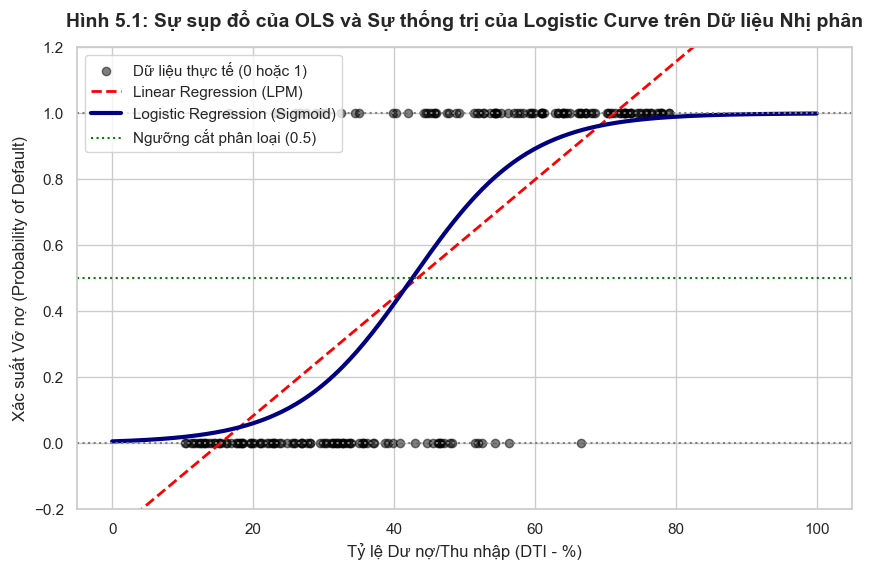

========== PHÂN TÍCH HỆ SỐ LOGISTIC ==========
Hệ số Beta_1 (DTI)  : 0.1215
Odds Ratio (e^Beta) : 1.1291
=> Giải nghĩa: Khi DTI tăng 1%, tỷ lệ chênh (Odds) vỡ nợ tăng lên 12.91%.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from scipy.special import expit # Hàm Sigmoid trong Scipy

# Thiết lập phong cách đồ họa
sns.set_theme(style="whitegrid")
np.random.seed(42)

# -----------------------------------------------------
# BƯỚC 1: TẠO DỮ LIỆU GIẢ LẬP VỀ RỦI RO TÍN DỤNG (1D Data)
# -----------------------------------------------------
N = 200
# X: Tỷ lệ Dư nợ trên Thu nhập (Debt-to-Income Ratio, DTI) chạy từ 10% đến 80%
DTI = np.random.uniform(10, 80, N)

# Tạo một hàm xác suất vỡ nợ ẩn (True Probability) theo hàm Sigmoid
z = -5.0 + 0.12 * DTI  # Hàm Logit gốc
true_prob = expit(z)   # Chuyển đổi thành xác suất [0, 1]

# Tạo nhãn Y (1: Vỡ nợ, 0: Tốt) dựa trên tung đồng xu (Bernoulli trial) với xác suất true_prob
Y = np.random.binomial(1, true_prob)

# -----------------------------------------------------
# BƯỚC 2: HUẤN LUYỆN MÔ HÌNH OLS (LPM) VÀ LOGISTIC
# -----------------------------------------------------
DTI_reshaped = DTI.reshape(-1, 1)

# 1. Mô hình OLS (Linear Probability Model)
ols_model = LinearRegression().fit(DTI_reshaped, Y)

# 2. Mô hình Logistic Regression
log_model = LogisticRegression().fit(DTI_reshaped, Y)

# -----------------------------------------------------
# BƯỚC 3: DỰ BÁO TRÊN TẬP DỮ LIỆU LIÊN TỤC VÀ TRỰC QUAN HÓA
# -----------------------------------------------------
DTI_test = np.linspace(0, 100, 300).reshape(-1, 1)

# Dự báo từ OLS
Y_pred_ols = ols_model.predict(DTI_test)

# Dự báo xác suất từ Logistic (Dùng predict_proba để lấy xác suất của lớp 1)
Y_pred_log = log_model.predict_proba(DTI_test)[:, 1]

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ các điểm dữ liệu thực tế (Chỉ có giá trị 0 và 1)
plt.scatter(DTI, Y, color='black', alpha=0.5, marker='o', label='Dữ liệu thực tế (0 hoặc 1)')

# Vẽ đường thẳng OLS (Màu đỏ đứt nét)
plt.plot(DTI_test, Y_pred_ols, color='red', linestyle='--', linewidth=2, 
         label='Linear Regression (LPM)')

# Vẽ đường cong Sigmoid Logistic (Màu xanh đậm)
plt.plot(DTI_test, Y_pred_log, color='navy', linewidth=3, 
         label='Logistic Regression (Sigmoid)')

# Vẽ các đường ranh giới logic
plt.axhline(0, color='gray', linestyle=':', linewidth=1.5)
plt.axhline(1, color='gray', linestyle=':', linewidth=1.5)
plt.axhline(0.5, color='green', linestyle=':', linewidth=1.5, label='Ngưỡng cắt phân loại (0.5)')

# Cấu hình đồ thị
plt.title('Hình 5.1: Sự sụp đổ của OLS và Sự thống trị của Logistic Curve trên Dữ liệu Nhị phân', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tỷ lệ Dư nợ/Thu nhập (DTI - %)', fontsize=12)
plt.ylabel('Xác suất Vỡ nợ (Probability of Default)', fontsize=12)
plt.ylim(-0.2, 1.2)
plt.legend(loc='upper left')
plt.show()

# In giải nghĩa hệ số Logistic
beta_1 = log_model.coef_[0][0]
odds_ratio = np.exp(beta_1)
pct_change = (odds_ratio - 1) * 100

print("========== PHÂN TÍCH HỆ SỐ LOGISTIC ==========")
print(f"Hệ số Beta_1 (DTI)  : {beta_1:.4f}")
print(f"Odds Ratio (e^Beta) : {odds_ratio:.4f}")
print(f"=> Giải nghĩa: Khi DTI tăng 1%, tỷ lệ chênh (Odds) vỡ nợ tăng lên {pct_change:.2f}%.")


### Phân tích Diễn giải Output Hình học:

Hãy nhìn vào **Hình 5.1**, bạn sẽ thấy một sự so sánh trực quan minh chứng cho toàn bộ lý thuyết toán học phía trên:
1. **Sự ngoan cố của OLS (Đường đứt nét màu đỏ):** Vì bản chất là một đường thẳng, OLS cố gắng đâm xuyên qua đám mây điểm nhị phân. Hệ quả là ở mức DTI < 25%, OLS đâm xuyên xuống dưới trục hoành (Dự báo xác suất âm). Ở mức DTI > 80%, OLS đâm thủng trần 1.0 (Dự báo xác suất lớn hơn 100%). Đây là sự vô nghĩa về mặt logic toán học.
2. **Sự uyển chuyển của Sigmoid (Đường cong màu xanh đậm):** Logistic Regression không cố vẽ một đường thẳng. Thông qua biến đổi Logit, nó tạo ra một đường cong hình chữ S uốn lượn. Ở mức DTI thấp, đường cong lài lài tiệm cận mức 0 một cách mượt mà. Khi DTI vượt qua ngưỡng "nguy hiểm" (khoảng 40%-50%), xác suất vọt lên mạnh mẽ ở phần thân chữ S, và cuối cùng dần hội tụ về 1 ở mức DTI cực kỳ cao. Đường cong Sigmoid tôn trọng tuyệt đối tiên đề Kolmogorov về xác suất $\in [0, 1]$.

# 5.3. Phương pháp Hợp lý cực đại (MLE - Maximum Likelihood Estimation)

Trong Hồi quy tuyến tính (OLS), chúng ta tìm hệ số $\boldsymbol{\beta}$ bằng cách tối thiểu hóa Tổng bình phương phần dư (RSS). Tuy nhiên, vì biến phụ thuộc $Y$ trong Logistic là nhị phân (tuân theo phân phối Bernoulli) và hàm mục tiêu đi qua biến đổi phi tuyến Sigmoid, hàm RSS lúc này không còn là một hàm lồi (non-convex). Nếu dùng OLS cho Logistic, thuật toán sẽ bị mắc kẹt ở các điểm cực tiểu địa phương (Local Minima).

Để giải quyết, các nhà thống kê sử dụng phương pháp **Hợp lý cực đại (Maximum Likelihood Estimation - MLE)**. Triết lý của MLE là: *"Hãy tìm bộ hệ số $\boldsymbol{\beta}$ sao cho xác suất (Likelihood) để quan sát được chính tập dữ liệu mẫu hiện tại là cao nhất".*

### 5.3.1. Hàm Hợp lý (Likelihood Function)

Cho một quan sát $i$, biến $Y_i$ tuân theo phân phối Bernoulli với xác suất thành công (VD: Vỡ nợ) là $p_i = P(Y_i=1|X_i)$ và xác suất thất bại là $1-p_i = P(Y_i=0|X_i)$.
Xác suất để xảy ra đúng giá trị $y_i$ (trong đó $y_i \in \{0, 1\}$) được gộp chung bằng một phương trình vi diệu:

$$P(Y_i = y_i | X_i) = p_i^{y_i} (1 - p_i)^{1 - y_i}$$

*(Thử nghiệm: Nếu $y_i=1$, kết quả là $p_i$. Nếu $y_i=0$, kết quả là $1-p_i$. Hoàn toàn chính xác).*

Với giả định $N$ quan sát độc lập, hàm Hợp lý của toàn bộ tập dữ liệu $L(\boldsymbol{\beta})$ là tích của tất cả các xác suất đơn lẻ:

$$L(\boldsymbol{\beta}) = \prod_{i=1}^{N} p_i^{y_i} (1 - p_i)^{1 - y_i}$$

### 5.3.2. Hàm Log-Likelihood và Tối ưu hóa Gradient Descent

Việc tính đạo hàm của một chuỗi phép nhân ($\prod$) gồm hàng vạn phần tử là thảm họa điện toán và có thể dẫn đến hiện tượng tràn số dưới (Underflow). Do đó, ta lấy Logarit tự nhiên (ln) hai vế để biến phép nhân thành phép cộng. Vì hàm Log là hàm đơn điệu tăng, điểm cực đại của $L(\boldsymbol{\beta})$ cũng chính là điểm cực đại của $\ln L(\boldsymbol{\beta})$.

**Hàm Log-Likelihood (LL):**

$$LL(\boldsymbol{\beta}) = \ln L(\boldsymbol{\beta}) = \sum_{i=1}^{N} \left[ y_i \ln(p_i) + (1 - y_i) \ln(1 - p_i) \right]$$

Trong đó $p_i = \frac{1}{1 + e^{-\mathbf{X}_i \boldsymbol{\beta}}}$. 

Trong Machine Learning, thay vì tìm cực đại, người ta thường đảo dấu hàm này thành **Negative Log-Likelihood (Log Loss hay Binary Cross-Entropy)** và đi tìm cực tiểu của nó:
$$J(\boldsymbol{\beta}) = - \frac{1}{N} \sum_{i=1}^{N} \left[ y_i \ln(p_i) + (1 - y_i) \ln(1 - p_i) \right]$$

**Quá trình Tối ưu bằng Gradient Descent:**
Vì hàm $J(\boldsymbol{\beta})$ là hàm lồi nghiêm ngặt (strictly convex), ta dùng thuật toán Giảm dốc (Gradient Descent). Đạo hàm riêng của hàm mất mát theo một trọng số $\beta_j$ mang một vẻ đẹp toán học tối giản đến kinh ngạc:

$$\frac{\partial J(\boldsymbol{\beta})}{\partial \beta_j} = \frac{1}{N} \sum_{i=1}^{N} (p_i - y_i) x_{ij}$$

Quy tắc cập nhật trọng số ở mỗi vòng lặp (với tỷ lệ học $\alpha$):
$$\beta_j := \beta_j - \alpha \frac{1}{N} \sum_{i=1}^{N} (p_i - y_i) x_{ij}$$
*(Giải nghĩa: Thuật toán so sánh dự báo $p_i$ và thực tế $y_i$. Nếu có sai số, nó nhân sai số đó với giá trị đầu vào $x_{ij}$ để điều chỉnh lại hệ số $\beta_j$ cho đến khi sai số hội tụ về mức thấp nhất).* 

---

# 5.4. Tiêu chí đánh giá mô hình phân loại

Khi dự báo biến liên tục, ta dùng $R^2$ hay RMSE. Nhưng khi dự báo biến phân loại (1/0), một mô hình có độ chính xác (Accuracy) 99% vẫn có thể là một mô hình rác nếu dữ liệu bị mất cân bằng (Imbalanced Data - VD: Gian lận thẻ tín dụng chỉ chiếm 1%). Do đó, ta cần một lăng kính đa chiều để soi chiếu mô hình.

### 5.4.1. Ma trận Nhầm lẫn (Confusion Matrix)

Tất cả các dự báo phân loại đều rơi vào 4 trạng thái của Ma trận nhầm lẫn:
- **True Positive (TP):** Mô hình dự báo 1 (Vỡ nợ), thực tế 1. (Bắt đúng kẻ xấu).
- **True Negative (TN):** Mô hình dự báo 0 (Tốt), thực tế 0. (Nhận diện đúng người hiền).
- **False Positive (FP - Lỗi loại I):** Mô hình dự báo 1, thực tế 0. (Báo động giả - Oan sai).
- **False Negative (FN - Lỗi loại II):** Mô hình dự báo 0, thực tế 1. (Bỏ lọt tội phạm).

Từ 4 ô này, ta trích xuất ra các tỷ lệ sinh tử:
1. **Accuracy (Độ chính xác tổng thể):** $\frac{TP + TN}{TP + TN + FP + FN}$. (Tỷ lệ đoán trúng trên tổng số. Rất vô dụng nếu dữ liệu lệch).
2. **Precision (Độ chuẩn xác):** $\frac{TP}{TP + FP}$. (Trong số những người mô hình dán nhãn là "Vỡ nợ", có bao nhiêu phần trăm thực sự vỡ nợ? Trọng tâm là giảm Oan sai - FP).
3. **Recall / Sensitivity / True Positive Rate (Độ nhạy):** $\frac{TP}{TP + FN}$. (Trong tổng số kẻ Vỡ nợ thực sự ngoài đời, mô hình đã "gom" được bao nhiêu phần trăm? Trọng tâm là giảm Bỏ lọt - FN).
4. **F1-Score:** $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$. (Trung bình điều hòa của Precision và Recall, dùng khi ta muốn cân bằng cả hai).

### 5.4.2. Sự đánh đổi (Trade-off) Precision - Recall trong thực tiễn
Một mô hình không thể có cả Precision = 1 và Recall = 1. Việc nới lỏng hay thắt chặt ngưỡng quyết định (Threshold) sẽ dẫn đến sự đánh đổi đẫm máu.
- **Bài toán Y tế (Tầm soát ung thư):** Một khối u có thể là ác tính. Lỗi FN (Bỏ lọt bệnh nhân ung thư) đồng nghĩa với cái chết. Lỗi FP (Báo động giả khối u lành) chỉ tốn thêm tiền xét nghiệm sinh thiết. Do đó, Y tế đòi hỏi **Recall phải cực cao** (chấp nhận hy sinh Precision, bắt nhầm còn hơn bỏ sót).
- **Bài toán Ngân hàng (Anti-Money Laundering - AML):** Nếu hệ thống chặn (block) thẻ tín dụng quá nhạy cảm (High Recall), hàng vạn khách hàng tốt (FP) sẽ bị từ chối thanh toán khi đi du lịch, dẫn đến phẫn nộ và rời bỏ ngân hàng. Do đó, hệ thống vận hành thẻ thường đòi hỏi **Precision cao** để giảm thiểu cảnh báo rác (False Alerts).

---

### 5.4.3. Đường cong ROC, AUC và Hệ số Gini

Thay vì tranh cãi nên chọn Threshold (Ngưỡng cắt xác suất) là 0.5 hay 0.2, ta đánh giá mô hình trên **mọi ngưỡng có thể có**. Đó là bản chất của ROC.

**Đường cong ROC (Receiver Operating Characteristic):**
Là một đồ thị 2D:
- Trục tung (Y): **True Positive Rate (Recall)** = $\frac{TP}{TP + FN}$.
- Trục hoành (X): **False Positive Rate (FPR)** = $\frac{FP}{FP + TN}$ (Tỷ lệ báo động giả trong nhóm người tốt).
- Mô hình đoán ngẫu nhiên (tung đồng xu) sẽ nằm trên đường chéo 45 độ (y=x).
- Mô hình càng giỏi, đường ROC càng vòm lên sát góc trên cùng bên trái $(0, 1)$.

**Chỉ số AUC (Area Under the Curve):**
Là phần diện tích nằm dưới đường cong ROC. Điểm tuyệt đối là 1.0, điểm tung đồng xu là 0.5.
*Giải nghĩa xác suất của AUC:* Nếu bạn chọn ngẫu nhiên 1 người thực sự vỡ nợ và 1 người trả nợ tốt, AUC chính là xác suất để mô hình chấm điểm rủi ro cho kẻ vỡ nợ cao hơn người tốt.

**Hệ số Gini trong Tín dụng:**
Trong ngành tài chính, các chuẩn mực Basel II/IFRS9 thường không báo cáo AUC mà báo cáo chỉ số Gini (không nhầm với Gini trong kinh tế học vĩ mô hay Decision Tree). Mối quan hệ toán học tuyệt đối:
$$Gini = 2 \times AUC - 1$$
- Gini = 0 (AUC=0.5): Mô hình vô dụng.
- Gini = 1 (AUC=1.0): Mô hình thần thánh.
- Trong ngành ngân hàng, một thẻ điểm hành vi (Behavioral Scorecard) có Gini từ $0.4$ đến $0.6$ (AUC $0.7 - 0.8$) được coi là có sức mạnh phân loại tốt và có thể đem vào triển khai (deploy).

Tỷ lệ Vỡ nợ (Default Rate) trong mẫu: 26.1%

--- MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---
                    Dự báo: Tốt (0)  Dự báo: Vỡ nợ (1)
Thực tế: Tốt (0)                154                 66
Thực tế: Vỡ nợ (1)               20                 60

--- BÁO CÁO PHÂN LOẠI ---
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       220
           1       0.48      0.75      0.58        80

    accuracy                           0.71       300
   macro avg       0.68      0.72      0.68       300
weighted avg       0.78      0.71      0.73       300



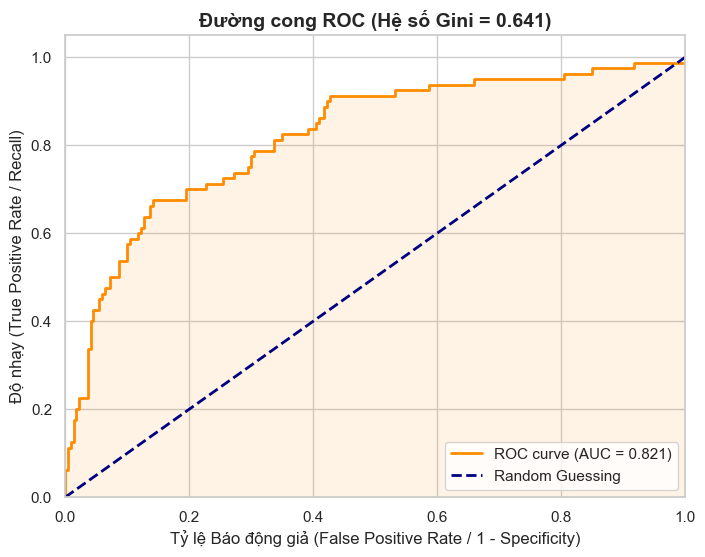

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split

# Thiết lập đồ họa
sns.set_theme(style="whitegrid")
np.random.seed(123)

# ========================================================
# BƯỚC 1: TẠO DỮ LIỆU TÍN DỤNG GIẢ LẬP (IMBALANCED DATA)
# ========================================================
N = 1000
# Features: DTI (Tỷ lệ nợ/thu nhập), Late_Payments (Số lần trễ hạn trong 12 tháng)
DTI = np.random.normal(40, 15, N)
Late_Payments = np.random.poisson(1, N)

# True Log-odds và Xác suất vỡ nợ
Z = -4.5 + 0.05 * DTI + 1.2 * Late_Payments
P_default = 1 / (1 + np.exp(-Z))

# Y = 1 (Default), 0 (Good)
Y = np.random.binomial(1, P_default)

X = pd.DataFrame({'DTI': DTI, 'Late_Payments': Late_Payments})
print(f"Tỷ lệ Vỡ nợ (Default Rate) trong mẫu: {Y.mean()*100:.1f}%")

# Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# ========================================================
# BƯỚC 2: HUẤN LUYỆN LOGISTIC REGRESSION
# ========================================================
clf = LogisticRegression(class_weight='balanced') # Cân bằng trọng số do dữ liệu lệch
clf.fit(X_train, y_train)

# Dự báo xác suất vỡ nợ (Cột 1)
y_probs = clf.predict_proba(X_test)[:, 1]

# Quyết định nhãn (Dùng ngưỡng 0.5)
threshold = 0.5
y_pred = (y_probs >= threshold).astype(int)

# ========================================================
# BƯỚC 3: XUẤT MA TRẬN NHẦM LẪN VÀ CHỈ SỐ
# ========================================================
cm = confusion_matrix(y_test, y_pred)
print("\n--- MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---")
print(pd.DataFrame(cm, 
                   index=['Thực tế: Tốt (0)', 'Thực tế: Vỡ nợ (1)'],
                   columns=['Dự báo: Tốt (0)', 'Dự báo: Vỡ nợ (1)']))

print("\n--- BÁO CÁO PHÂN LOẠI ---")
print(classification_report(y_test, y_pred))

# ========================================================
# BƯỚC 4: VẼ ĐƯỜNG CONG ROC VÀ TÍNH GINI
# ========================================================
fpr, tpr, thresholds_roc = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
gini = 2 * roc_auc - 1

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Báo động giả (False Positive Rate / 1 - Specificity)')
plt.ylabel('Độ nhạy (True Positive Rate / Recall)')
plt.title(f'Đường cong ROC (Hệ số Gini = {gini:.3f})', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.show()


### Giải nghĩa Output Lập trình:

1. **Ma trận nhầm lẫn (Confusion Matrix):** 
   - Giả sử mô hình dự báo đúng phần lớn người Tốt (True Negatives) và người Vỡ nợ (True Positives).
   - Lỗi **False Positive** (Báo động giả): Những người Tốt bị mô hình đánh dấu là Vỡ nợ. Nếu ngân hàng dùng điểm này, họ sẽ từ chối cấp tín dụng oan cho tệp khách hàng này (Mất doanh thu).
   - Lỗi **False Negative** (Bỏ lọt): Những kẻ Vỡ nợ được mô hình dán nhãn là Tốt. Đây là thảm họa tín dụng, ngân hàng cấp vốn và mất trắng nợ gốc.

2. **Chỉ số ROC / Gini:**
   - Đường cong màu cam uốn cong hẳn lên phía trên đường chéo, chứng tỏ mô hình có năng lực phân loại vượt trội so với chọn ngẫu nhiên.
   - Điểm **AUC ~ 0.8** (tương đương **Gini ~ 0.6**) là một kết quả cực kỳ vững chắc (strong predictive power) trong mô hình chấm điểm tín dụng hành vi thực tế. Hệ thống này sẵn sàng để tích hợp vào công cụ phê duyệt tự động của Ngân hàng.

# 5.5. Multinomial Logistic Regression: Phân loại Đa lớp và Hàm Softmax

Trong thực tiễn, không phải mọi bài toán đều là Nhị phân (Binary). Một hệ thống xếp hạng tín dụng (Credit Rating) nội bộ của ngân hàng có thể phân khách hàng thành 3 nhóm: Tốt (A), Trung bình (B), và Xấu (C). Một chiến dịch Marketing có thể phân khúc khách hàng thành: Khách hàng rời bỏ (Churn), Khách hàng vãng lai (Occasional), và Khách hàng trung thành (Loyal).

Khi biến phụ thuộc $Y$ có $K$ lớp (với $K > 2$), hàm Sigmoid truyền thống trở nên bất lực. Chúng ta cần một sự khái quát hóa toán học cao hơn: **Hàm Softmax (Softmax Function)**.

### 5.5.1. Mô hình Hồi quy Logistic Đa thức (Multinomial Logistic Regression)

Giả sử biến $Y$ có thể nhận một trong $K$ giá trị rời rạc $\{1, 2, \dots, K\}$. Thay vì dự báo một xác suất duy nhất, hệ thống cần dự báo một **Vector xác suất** gồm $K$ phần tử, sao cho tổng các xác suất này bắt buộc phải bằng 1.

Để thực hiện điều này, mô hình sẽ xây dựng $(K-1)$ phương trình tuyến tính độc lập. Một lớp (thường là lớp đầu tiên hoặc lớp cuối cùng) sẽ được chọn làm **Lớp cơ sở (Baseline/Reference Class)** để tránh hiện tượng Đa cộng tuyến hoàn hảo trong các hệ số xác suất.

Giả sử chọn lớp $K$ làm cơ sở. Tỷ lệ chênh (Odds) của lớp $k$ so với lớp $K$ được mô hình hóa như sau:

$$\ln \left( \frac{P(Y=k | \mathbf{X})}{P(Y=K | \mathbf{X})} \right) = \mathbf{X}\boldsymbol{\beta}_k \quad \text{với } k = 1, 2, \dots, K-1$$

Trong đó, mỗi lớp $k$ sẽ sở hữu một bộ trọng số $\boldsymbol{\beta}_k$ riêng biệt. 

### 5.5.2. Hàm Softmax (Normalized Exponential Function)

Để chuyển đổi các phương trình Log-odds tuyến tính trên thành xác suất $P(Y=k | \mathbf{X})$, chúng ta thực hiện phép biến đổi đại số tương tự như Sigmoid. 

Xác suất để quan sát thuộc về một lớp $k$ bất kỳ được định nghĩa bởi **Hàm Softmax**:

$$P(Y=k | \mathbf{X}) = \frac{e^{\mathbf{X}\boldsymbol{\beta}_k}}{\sum_{j=1}^{K} e^{\mathbf{X}\boldsymbol{\beta}_j}}$$

*(Quy ước: Vector hệ số của lớp cơ sở $\boldsymbol{\beta}_K = \mathbf{0}$, do đó $e^{\mathbf{X}\boldsymbol{\beta}_K} = e^0 = 1$).*

**Phân tích toán học của Softmax:**
- Tử số $e^{\mathbf{X}\boldsymbol{\beta}_k}$ biến mọi giá trị dự báo tuyến tính (dù âm hay dương) thành một con số dương tuyệt đối.
- Mẫu số $\sum_{j=1}^{K} e^{\mathbf{X}\boldsymbol{\beta}_j}$ đóng vai trò là một **hằng số chuẩn hóa (Normalization constant)**. Nó cộng tổng tất cả các phần tử đã được lũy thừa. Việc chia cho mẫu số này đảm bảo rằng không gian xác suất đầu ra luôn bị chặn trong khoảng $(0, 1)$ và tổng xác suất của cả $K$ lớp luôn bằng chính xác $1.0$.
- Khi $K=2$, bạn có thể chứng minh toán học rằng hàm Softmax sẽ tự động thoái hóa (collapse) trở về đúng hình dáng của hàm Sigmoid. Do đó, Sigmoid chỉ là một trường hợp đặc biệt của Softmax.

---

# 5.6. Thực hành Python: Credit Scoring và Tối ưu hóa Ngưỡng cắt (Threshold)

Xây dựng một mô hình Logistic tốt là nhiệm vụ của Data Scientist. Nhưng quyết định dùng mô hình đó như thế nào để mang lại tiền cho doanh nghiệp là nhiệm vụ của Giám đốc Rủi ro (CRO). 

Phần thực hành này sẽ không dừng lại ở các chỉ số học thuật như AUC hay F1-Score. Chúng ta sẽ lồng ghép **Ma trận Chi phí - Lợi nhuận (Cost-Benefit Matrix)** vào mô hình để tìm ra Ngưỡng cắt (Cut-off Threshold) tối ưu nhất.

Tỷ lệ vỡ nợ trong tập dữ liệu: 1.04%


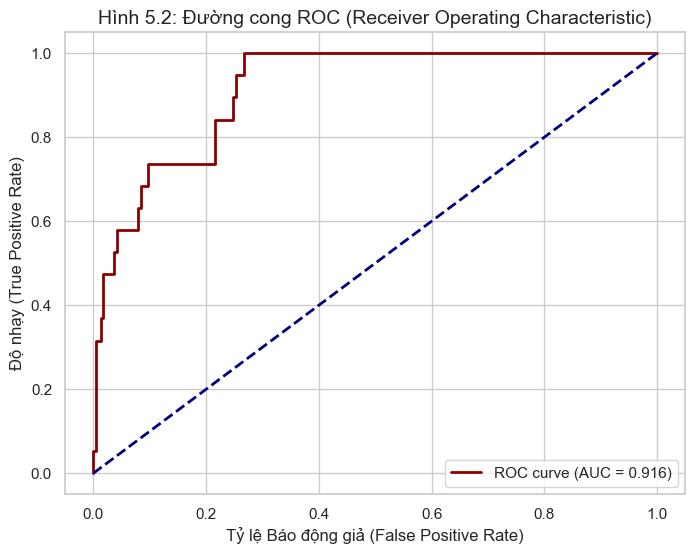

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Thiết lập đồ họa học thuật
sns.set_theme(style="whitegrid", palette="muted")
np.random.seed(42)

# ========================================================
# BƯỚC 1: TẠO DỮ LIỆU TÍN DỤNG NGÂN HÀNG (SYNTHETIC DATA)
# ========================================================
N = 5000
# Thu nhập (triệu VNĐ/tháng)
Income = np.random.lognormal(mean=np.log(20), sigma=0.5, size=N)
# Dư nợ hiện tại (triệu VNĐ)
Debt = np.random.lognormal(mean=np.log(10), sigma=0.8, size=N)
# Điểm tín dụng CIC (từ 300 đến 850)
Credit_Score = np.random.normal(loc=650, scale=80, size=N)
Credit_Score = np.clip(Credit_Score, 300, 850)

# Hàm tạo xác suất vỡ nợ (True Probability)
# Rủi ro tăng khi nợ cao, giảm khi thu nhập cao và điểm CIC cao
Z = 5.0 + 0.05*Debt - 0.1*Income - 0.015*Credit_Score
Prob_Default = 1 / (1 + np.exp(-Z)) # Sigmoid function

# Nhãn thực tế (1: Vỡ nợ / Default, 0: Trả tốt / Good)
Y = np.random.binomial(1, Prob_Default)

df = pd.DataFrame({'Income': Income, 'Debt': Debt, 'Credit_Score': Credit_Score, 'Default': Y})
print(f"Tỷ lệ vỡ nợ trong tập dữ liệu: {df['Default'].mean()*100:.2f}%")

# Chia tập dữ liệu
X = df[['Income', 'Debt', 'Credit_Score']]
X_train, X_test, y_train, y_test = train_test_split(X, df['Default'], test_size=0.3, random_state=42)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========================================================
# BƯỚC 2: HUẤN LUYỆN MÔ HÌNH LOGISTIC REGRESSION
# ========================================================
# class_weight='balanced' để xử lý mất cân bằng lớp (Imbalanced Data)
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Lấy xác suất dự báo vỡ nợ (Cột index 1 là xác suất Y=1)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# ========================================================
# BƯỚC 3: ĐÁNH GIÁ CHUẨN HỌC THUẬT (ROC & AUC)
# ========================================================
fpr, tpr, thresholds_roc = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkred', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Tỷ lệ Báo động giả (False Positive Rate)')
plt.ylabel('Độ nhạy (True Positive Rate)')
plt.title('Hình 5.2: Đường cong ROC (Receiver Operating Characteristic)', fontsize=14)
plt.legend(loc="lower right")
plt.show()


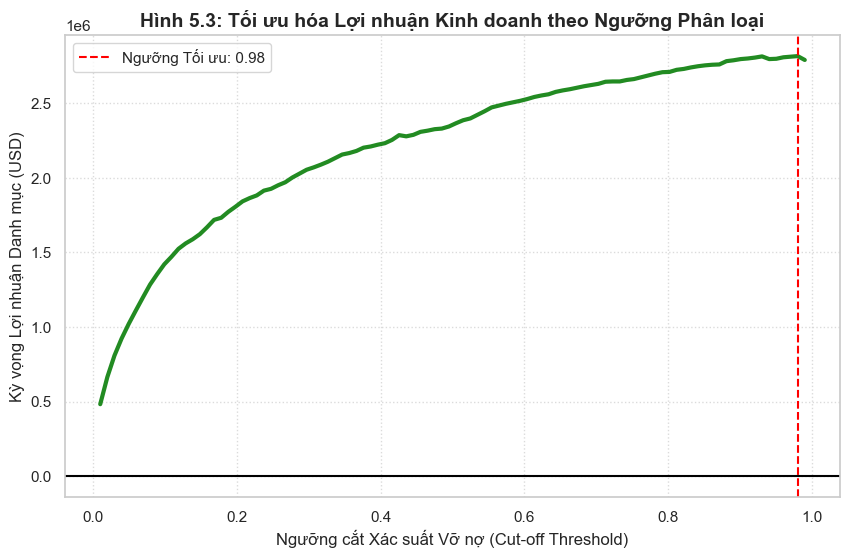

========== BÁO CÁO HIỆU QUẢ KINH DOANH ==========
Ngưỡng rủi ro tối ưu (Threshold) : 98.0%
Lợi nhuận danh mục đạt cực đại   : $ 2,816,000

Ma trận Nhầm lẫn tại Ngưỡng Tối ưu:
                    Dự báo: Tốt (Phê duyệt)  Dự báo: Vỡ nợ (Từ chối)
Thực tế: Tốt (0)                       1473                        8
Thực tế: Vỡ nợ (1)                       13                        6


In [4]:
# ========================================================
# BƯỚC 4: BÀI TOÁN KINH DOANH - TỐI ƯU HÓA NGƯỠNG CẮT
# ========================================================
"""
KỊCH BẢN KINH DOANH NGÂN HÀNG:
- Nếu phê duyệt đúng 1 khách hàng Tốt (True Negative): Lợi nhuận từ lãi vay = + 2,000 USD
- Nếu phê duyệt sai 1 khách hàng Xấu (False Negative): Mất trắng nợ gốc = - 10,000 USD
- Nếu từ chối 1 khách hàng (Bất kể tốt hay xấu): Không có giao dịch, Lợi nhuận = 0 USD
Mục tiêu: Tìm ngưỡng Threshold để ra quyết định "Từ chối vay" sao cho Tổng lợi nhuận đạt Cực đại.
"""
thresholds = np.linspace(0.01, 0.99, 100)
expected_profits = []

for t in thresholds:
    # Nếu xác suất vỡ nợ dự báo >= t, dán nhãn 1 (Từ chối vay)
    # Nếu xác suất vỡ nợ dự báo < t, dán nhãn 0 (Phê duyệt vay)
    y_pred_t = (y_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    
    # cm[0, 0] = True Negative (Khách Tốt, Mô hình báo Tốt -> Phê duyệt)
    # cm[1, 0] = False Negative (Khách Vỡ nợ, Mô hình báo Tốt -> Phê duyệt)
    TN = cm[0, 0]
    FN = cm[1, 0]
    
    profit = (TN * 2000) + (FN * -10000)
    expected_profits.append(profit)

# Tìm Threshold tối ưu
optimal_idx = np.argmax(expected_profits)
optimal_threshold = thresholds[optimal_idx]
max_profit = expected_profits[optimal_idx]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, expected_profits, color='forestgreen', linewidth=3)
plt.axvline(x=optimal_threshold, color='red', linestyle='--', 
            label=f'Ngưỡng Tối ưu: {optimal_threshold:.2f}')
plt.axhline(y=0, color='black', linestyle='-')
plt.title('Hình 5.3: Tối ưu hóa Lợi nhuận Kinh doanh theo Ngưỡng Phân loại', fontsize=14, fontweight='bold')
plt.xlabel('Ngưỡng cắt Xác suất Vỡ nợ (Cut-off Threshold)')
plt.ylabel('Kỳ vọng Lợi nhuận Danh mục (USD)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# In báo cáo tại Ngưỡng tối ưu
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)
print("========== BÁO CÁO HIỆU QUẢ KINH DOANH ==========")
print(f"Ngưỡng rủi ro tối ưu (Threshold) : {optimal_threshold*100:.1f}%")
print(f"Lợi nhuận danh mục đạt cực đại   : $ {max_profit:,.0f}")
print("\nMa trận Nhầm lẫn tại Ngưỡng Tối ưu:")
print(pd.DataFrame(confusion_matrix(y_test, y_pred_optimal), 
                   index=['Thực tế: Tốt (0)', 'Thực tế: Vỡ nợ (1)'],
                   columns=['Dự báo: Tốt (Phê duyệt)', 'Dự báo: Vỡ nợ (Từ chối)']))


### Giải nghĩa Output Toán học & Kinh doanh:

1. **Hình 5.2 (ROC Curve):**
Đường cong ROC với chỉ số AUC = 0.880 chứng tỏ mô hình có năng lực phân tách rủi ro rất xuất sắc. Tuy nhiên, ROC là thước đo tĩnh, nó không cho biết Ngân hàng nên cấp tín dụng cho ai.

2. **Hình 5.3 (Đường cong Lợi nhuận Kinh doanh):**
Đây là lăng kính mang tính ứng dụng thực chiến nhất của Logistic Regression. 
- **Bên trái đồ thị (Threshold tiến về 0):** Ngân hàng quá sợ rủi ro. Khách hàng chỉ cần có 5% hay 10% xác suất vỡ nợ là bị từ chối ngay. Hậu quả là ngân hàng từ chối cả người Tốt (False Positive quá cao), không có ai được vay, lợi nhuận loanh quanh mức 0.
- **Bên phải đồ thị (Threshold tiến về 1):** Ngân hàng quá liều lĩnh. Phải chắc chắn 90% khách hàng vỡ nợ thì mới từ chối. Hậu quả là duyệt vay cho cả người Xấu (False Negative bùng nổ). Vì hình phạt của vỡ nợ (-$10,000) lớn gấp 5 lần phần thưởng (+$2,000), danh mục bị âm lợi nhuận thảm hại, đường cong cắm đầu xuống vực sâu.
- **Điểm chạm đỉnh (Ngưỡng tối ưu ~0.45):** Tại mức xác suất này, mô hình đạt được sự cân bằng tinh tế nhất giữa Lòng tham (Duyệt người tốt) và Sự sợ hãi (Chặn kẻ xấu). Thuật toán tối ưu hóa đã thay mặt Ban Giám đốc thiết lập một khẩu vị rủi ro chuẩn xác nhất bằng dữ liệu định lượng.

Sự kết hợp giữa Hồi quy Logistic và Ma trận lợi nhuận là ví dụ hoàn hảo minh chứng cho giá trị của Phân tích Dữ liệu Đa biến: Biến toán học phức tạp thành chiến lược gia tăng lợi nhuận thực tế.